## Homework 2

# Kavin Kannan 3/14/2025           

Part 1: Loading and Plotting the CO2 Data
Skim through the original data file, co2_mm_mlo.txt, and find the description for each data column.
The first two columns are the year and month that the data were collected. These are combined to make
a single “decimal date” in the third column. The fourth column contains the monthly average CO2
concentration measurements, and these include seasonal variations in CO2 level. These seasonal
variations are corrected for (using a linear interpolation) in the fifth column. The uncertainties in the
monthly mean are in the last (8th) column. Make note of the units for the quantities in each column.

In [163]:
import numpy as np
from numpy import sin, cos
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
import scipy
from scipy.optimize import curve_fit
import pandas as pd

A. (5 pts) Read in the data in co2_ mm_mlo.csv using numpy’s np.loadtxt(...) (skip two rows) or a
pandas dataframe df = pd.read_csv(...) (skip 1 row). If the former, store the incoming data as
an array and then slice the array to reference the data columns you will use when making your plots.
If using a pandas dataframe, convert the relevant data columns to numpy arrays using, for example,
df['decimal date'].to_numpy(). Use the third data column for the time, the fourth data
column for the CO2 concentration, and the last column for the uncertainties in column 4 data.

In [219]:
co2_data = np.loadtxt("co2_mm_mlo.txt", skiprows=2)
co2_time = co2_data[:, 2] #Loading the third column as Time
co2_concentration = co2_data[:, 3] #Loading the fourth column as CO2 Concentration
co2_concentration_uncertainties = co2_data[:, -1] #Loading the last column as Uncertainties in CO2 Concentration

B. (5 pts) You will notice that though the data record begins in March 1958, the uncertainties in the
data, shown in the last column, are not known until May 1974, and are listed simply as -0.99. Read
through and replace (using code) all negative and zero values in this last column with the mean of all
the positive entries in this column, else you will have trouble with the curve-fitting.

In [222]:
co2_concentration_uncertainties_positive = co2_concentration_uncertainties[co2_concentration_uncertainties > 0] #Filtering out all negative entries in uncertainties
co2_concentration_uncertainties_positive_mean = np.mean(co2_concentration_uncertainties_positive) #Calculating the mean of the positive stds
for i in range(len(co2_concentration_uncertainties)): #Replacing each uncertainty of 0 or -0.99 with the mean uncertainty
    if co2_concentration_uncertainties[i] == -0.99 or co2_concentration_uncertainties[i] == 0:
        co2_concentration_uncertainties[i] = co2_concentration_uncertainties_positive_mean #Replacing entries of 0 or -0.99 with the positive mean

C. (5 pts) Plot the data for CO2 concentration vs time. To better see the trend, plot without symbols.
Describe what you see. Next, plot a limited range (say a decade) of the data with symbols including
error bars (last column) so you can see how the size of the error bars compare with the seasonal
oscillation. Be sure to put in axis labels, with units, and a title. Do this for a decade post 1974.

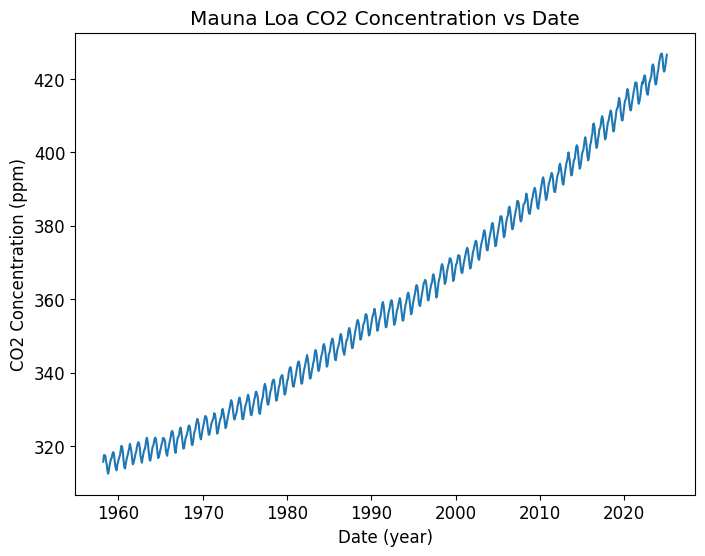

In [241]:
plt.figure(figsize=(8, 6)) #Plotting the graph of all data for CO2 vs time
plt.rc('font', size=12)        
plt.plot(co2_time, co2_concentration) #Plotting without symbols
plt.xlabel('Date (year)')
plt.ylabel('CO2 Concentration (ppm)')
plt.title ("Mauna Loa CO2 Concentration vs Date")
plt.show()

I see an oscillating sawlike graph that has an increasing background variable. The sawlike pattern keeps repeating at the same interval, with the same amplitude, however, the background causes an increase in the overall value of CO2 Concentration. 

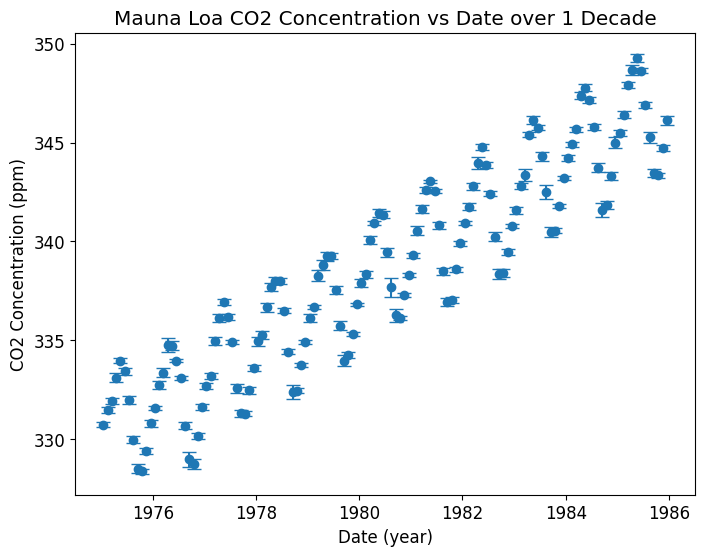

In [273]:
co2_time_decade = co2_time[(co2_time >= 1975) & (co2_time < 1986)] #Creating the data for 10 years plot after 1975 and before 1986
co2_concentration_decade = co2_concentration[(co2_time > 1975) & (co2_time < 1986)]
co2_concentration_uncertainties_decade = co2_concentration_uncertainties[(co2_time > 1975) & (co2_time < 1986)]

plt.figure(figsize=(8, 6)) #Plotting the graph of 10 years data 
plt.errorbar(co2_time_decade, co2_concentration_decade, yerr = co2_concentration_uncertainties_decade, fmt='o', capsize = 5) #Including Uncertainties and plotting with symbols
plt.xlabel('Date (year)')
plt.ylabel('CO2 Concentration (ppm)')
plt.title ("Mauna Loa CO2 Concentration vs Date over 1 Decade")
plt.show()

The error bars are a lot smaller than the seasonal oscillations!

D. (5 pts) You should notice that the data have a pronounced oscillation of about 1 year due to seasonal
variations in CO2 levels. This is superimposed on a clearly visible trend in the data. Plot data over a
two-year period and estimate the magnitude of the oscillation. What is the source of this oscillation?
(You may have to do a little research for this.) How does the oscillation magnitude compare with the
size of the uncertainties in the data (column 8) – i.e. can you say definitively that the oscillation is a
feature? Answer in a markdown cell.

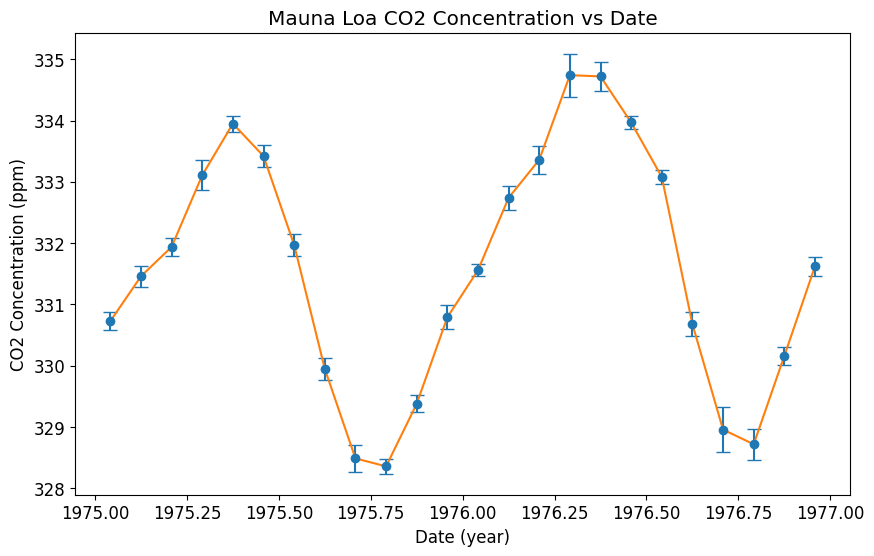

In [305]:
co2_time_2years = co2_time[(co2_time > 1975) & (co2_time < 1977)] #Creating the data for 2 years plot
co2_concentration_2years = co2_concentration[(co2_time > 1975) & (co2_time < 1977)]
co2_concentration_uncertainties_2years = co2_concentration_uncertainties[(co2_time > 1975) & (co2_time < 1977)]

plt.figure(figsize=(10, 6)) #Plotting the graph of 2 years data
plt.errorbar(co2_time_2years, co2_concentration_2years, yerr = co2_concentration_uncertainties_2years, fmt='o', capsize = 5)
plt.plot(co2_time_2years, co2_concentration_2years)
plt.xlabel('Date (year)')
plt.ylabel('CO2 Concentration (ppm)')
plt.title ("Mauna Loa CO2 Concentration vs Date")
plt.show()

The magnitude of the oscillation seems to be around 6 ppm (meaning the amplitude is around 3 ppm). The variation in the data corresponds to the seasons. The peak seems to occur around March and April when plants (which are our main consumers of CO2) are still decomposing (releasing CO2) and simultaneously still not fully returned to photosynthesis. Throughout Spring, as more plants resume photosynthesis, more CO2 is absorbed in order to sustain them. As Fall approaches, throughout Summer, the decrease in CO2 caps out with most plants in full work. Then as Fall approaches, the plants begin to wisp away, beginning the increase of CO2 at 3/4 through the year (September) Once snowfall hits, almost all plants are slowed or completely hindered in their photosynthesis, leading to the constant CO2 increase until Spring comes once again. The magnitude of the oscillations is way greater than the uncertainties in the CO2 concentration. The oscillation must be a feature as it's a global phenomena that we're observing at a local scale. This oscillation is caused by seasonal variations in vegetation and clearly not just noise seeing as the uncertainties are way smaller than the effect we're observing.

E. (5 points) Smooth out the annual variation by making yearly averages of the data. To make things
simple, ignore the years that do not have 12 months of data (1958 and 2025). For the remaining
years, calculate the average over twelve months. This should give you a data set with annual average
CO2 levels. Plot this on top of the original data. Does this make the trend in the data clearer?
Compare this plotted average to a plot of the data in column 5, which are “deseasonalized” values.

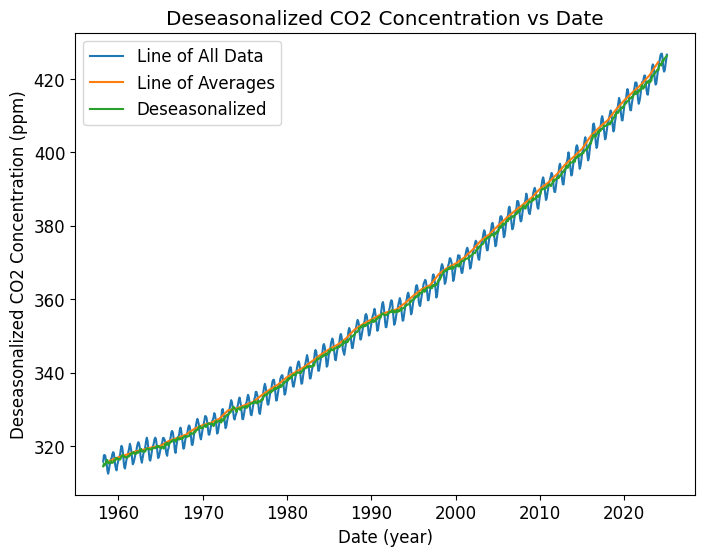

In [344]:
co2_time_average = np.zeros(66)
co2_concentration_average = np.zeros(66)
co2_concentration_uncertainties_average = np.zeros(66)
for i in range(66):
    co2_time_average[i] = i + 1959
    co2_concentration_average[i] = np.mean(co2_concentration[(co2_time > i + 1959) & (co2_time < i + 1960)])
    co2_concentration_uncertainties_average[i] = np.mean(co2_concentration_uncertainties[(co2_time > i + 1959) & (co2_time < i + 1960)])

plt.figure(figsize=(8, 6)) #Plotting the graph of all data
plt.rc('font', size=12)        
plt.plot(co2_time, co2_concentration, label = "Line of All Data") 
plt.xlabel('Date (year)')
plt.ylabel('CO2 Concentration (ppm)')
plt.title ("CO2 Concentration vs Date")

plt.plot(co2_time_average, co2_concentration_average, label = "Line of Averages") #Plotting the graph of calculated yearly average

co2_concentration_deseasonalized = co2_data[:, 4]
plt.plot(co2_time, co2_concentration_deseasonalized, label="Deseasonalized")
plt.xlabel('Date (year)')
plt.ylabel('Deseasonalized CO2 Concentration (ppm)')
plt.title ("Deseasonalized CO2 Concentration vs Date")
plt.legend()
plt.show()

Our calculated average line looks very similar to the deseasonalized line, even mimicking the slight drops and gains throughout certain years! This is great news and means that the deasonalized data is almost equivalent to the average yearly data.

Part 2. Linear and Quadratic fits
We will now try to fit the trend in the data. To make our fits a little easier, it will be better to work with
a time axis that starts at 0. This means that our new time axis is “Years since March 1958”, the first time
point in the data set. Create a new list/array for time that is equal to the old one minus the initial decimal
time value. Check that the new time array has its first entry equal to 0. Keep the CO2 level array
unchanged.
The function you will use to do the fits is scipy.optimize.curve_fit(). Be sure to include the
following in your program: from scipy.optimize import curve_fit.

A. (10 pts) Define a linear polynomial function, then perform a linear fit to the data, and find the best
values of the intercept and slope. Use the data uncertainties in your fit (using the keyword sigma in
curve_fit()).

a. Plot the data and the best fit line together.

b. Print the best fit parameter values +/- (uncertainties) and reduced chi-squared value to the
screen. (Include units).

c. Make a separate plot of the residuals (the difference between the fit and the data). You can do
this as a smaller subplot. What information do we get from residuals? Discuss.

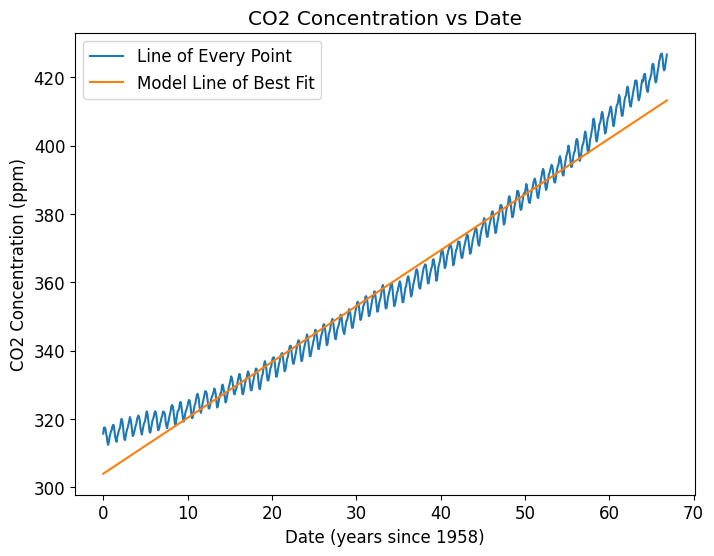

Reduced chi-squared = 827.85673
a = 1.63467 +/- 0.01851 ppm/years since 1958
b = 303.97816 +/- 0.72222 ppm


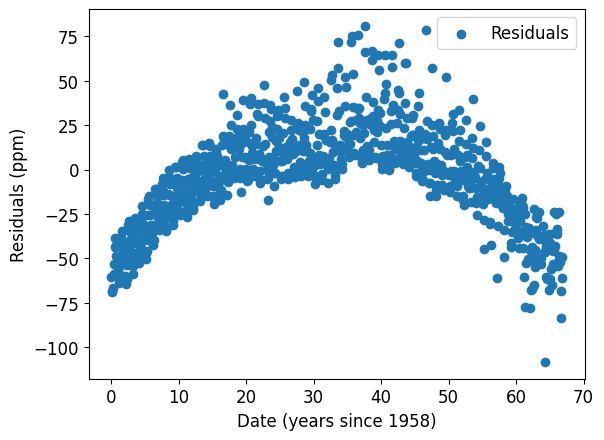

In [347]:
co2_time_adjusted = co2_time - min(co2_time) #Creating the adjusted time array starting at the first day data was taken

def Linear(x, a, b): #Defining a linear function
    """Model fit function: straight line, or polynomial of order 1"""
    return a*x +b

#Using curve_fit to fit the data:
pp = 2 #Number of fit parameters
nn = len(co2_time_adjusted) #Number of data points
guesses = (1, 1) #Initial parameter guesses
(al, bl),cc = curve_fit(Linear, co2_time_adjusted, co2_concentration, p0=guesses, sigma=co2_concentration_uncertainties) #Store fit parameters in a, b
(ual,ubl) = 2*np.sqrt(np.diag(cc)) #2-sigma uncertainties of a, b

#Plot data and model together
co2_time_mod = np.linspace(co2_time_adjusted[0], co2_time_adjusted[-1], 100)  #Generate x values between initial and final x data
co2_concentration_mod = Linear(co2_time_mod, al, bl)   #Model fitting function values at the x points we have generated

plt.figure(figsize=(8, 6)) #Plotting the graph of all data
plt.rc('font', size=12)        
plt.plot(co2_time_adjusted, co2_concentration, label = "Line of Every Point") 
plt.xlabel('Date (years since 1958)')
plt.ylabel('CO2 Concentration (ppm)')
plt.title ("CO2 Concentration vs Date")
plt.plot(co2_time_mod,co2_concentration_mod, label="Model Line of Best Fit") #Plotting the model
plt.legend()
plt.show()

#Calculate reduced chi-squared
co2_concentration_fit = Linear(co2_time_adjusted, al, bl) #This calculates the model fitting function at the x values of the data
co2_concentrations_residuals_unnormalized = (co2_concentration_fit - co2_concentration) / co2_concentration_uncertainties
co2_concentration_residuals = ((co2_concentration_fit - co2_concentration)**2)/(co2_concentration_uncertainties**2)   #This generates a array of the squared differences between data and model
chisqr = sum(co2_concentration_residuals)/(nn-pp) #Compute reduced chi-squared
print(f'Reduced chi-squared = {chisqr:3.5f}')

#Print calculated curve fit values with units
print(f'a = {al:3.5f} +/- {ual:3.5f} ppm/years since 1958') 
print(f'b = {bl:3.5f} +/- {ubl:3.5f} ppm')

#Plot separate residuals graph
plt.scatter(co2_time_adjusted, co2_concentrations_residuals_unnormalized, label="Residuals")
plt.xlabel("Date (years since 1958)")
plt.ylabel("Residuals (ppm)")
plt.legend()
plt.show()

B. (10 pts) Next, investigate whether you can find a better fit to the data. Define a quadratic fit function
and use it to fit to the data, and extract the best values of the fit parameters.

a. Plot the data and the best fit line together.

b. Print the best fit parameter values +/-  (uncertainties) and reduced chi-squared value to the
screen. (Include units).

c. Make a plot of the residuals. Once again, this can be done as a smaller subplot.

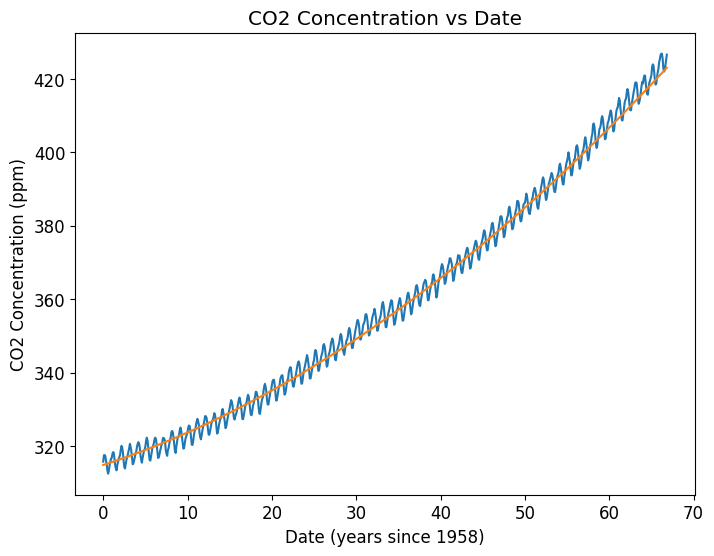

Reduced chi-squared = 201.41151
a = 0.01291 +/- 0.00052 ppm/years since 1958 squared
b = 0.75755 +/- 0.03631 ppm/years since 1958
c = 314.79526 +/- 0.56098 ppm


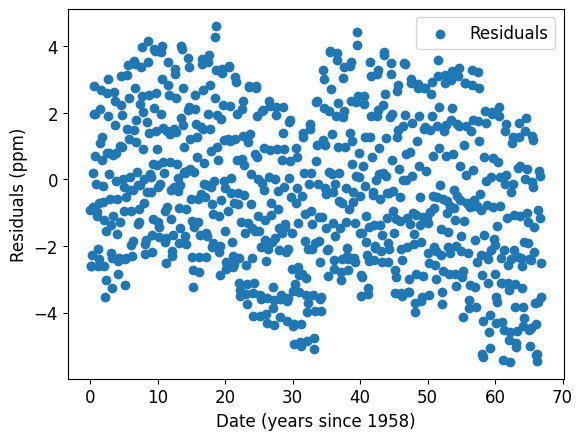

In [348]:
def Quadratic(x, a, b, c): #Defining a function for the quadratic fit
    """Model fit function: straight line, or polynomial of order 1"""
    return a*x*x + b*x + c

#Use curve_fit to fit the data:
pp = 3 #Number of fit parameters
nn = len(co2_time_adjusted) #Number of data points
guesses = (1, 1, 1) #Initial parameter guesses
(aq, bq, cq),cc = curve_fit(Quadratic, co2_time_adjusted, co2_concentration, p0=guesses, sigma=co2_concentration_uncertainties) #Store fit parameters in a, b
(uaq,ubq, ucq) = 2*np.sqrt(np.diag(cc)) #2-sigma uncertainties of a, b, and c

#Plot data and model together
co2_time_mod = np.linspace(co2_time_adjusted[0], co2_time_adjusted[-1], 100)  #Generate x values between initial and final x data
co2_concentration_mod = Quadratic(co2_time_mod, aq, bq, cq)   #Model fitting function values at the x points we have generated

plt.figure(figsize=(8, 6)) #Plotting the graph of all data
plt.rc('font', size=12)        
plt.plot(co2_time_adjusted, co2_concentration, label = "Line of Every Point") 
plt.xlabel('Date (years since 1958)')
plt.ylabel('CO2 Concentration (ppm)')
plt.title ("CO2 Concentration vs Date")
plt.plot(co2_time_mod,co2_concentration_mod, label = "Model Line of Best Fit") #Plotting the model
plt.show()

#Calculate reduced chi-squared
co2_concentration_fit = Quadratic(co2_time_adjusted, aq, bq, cq) #This calculates the model fitting function at the x values of the data
co2_concentration_residuals_unnormalized = co2_concentration_fit - co2_concentration
co2_concentration_residuals = (co2_concentration_fit - co2_concentration)**2/co2_concentration_uncertainties**2   #This generates a array of the squared differences between data and model
chisqr = sum(co2_concentration_residuals)/(nn-pp) #Compute reduced chi-squared
print(f'Reduced chi-squared = {chisqr:3.5f}')

#Print calculated curve fit values with units
print(f'a = {aq:3.5f} +/- {uaq:3.5f} ppm/years since 1958 squared') 
print(f'b = {bq:3.5f} +/- {ubq:3.5f} ppm/years since 1958')
print(f'c = {cq:3.5f} +/- {ucq:3.5f} ppm')

#Plot separate residuals graph
plt.scatter(co2_time_adjusted, co2_concentration_residuals_unnormalized, label="Residuals")
plt.xlabel("Date (years since 1958)")
plt.ylabel("Residuals (ppm)")
plt.legend()
plt.show()

C. (5 pts) Assess your fits in two ways. First, compare the reduced chi-squared for each fit. How well is
the data described by a linear function? A quadratic function? Put your observations in a markdown
cell.

The chi-squared for the linear fit is 827, whereas the chi-squared for the quadratic fit is 200. Just based on this fact alone, we can observe that 200 is way closer to 1 (the ideal fit) than 827, thus, the quadratic fit is better. The chi square is effectively comparing how far away each point is from the line and minimizing it. So for the minimum linear fit, the sum of all of those "residuals" normalized (that's why we reduce it by dividing it by nn-pp) is 827. Comparing that with the same calculation for the quadratic fit of 200, we can see that the normalized distances are way less than with the linear fit. Thus, the quadratic fit is better!

The data is described okay by a linear function. Observing the first graph, we can see that the middle section of the data is relatively well covered, however, near the ends the fit isn't even touching the line. This isn't exactly what we want, as our line of best fit should touch the data. So, we went a step up (to the quadratic fit). Observing the third graph, we can see that the curve is smooth and follows the line of all data pretty accurately, waning off slightly near the end. This is consistent with a good fit as all the data's distance from the curve of best fit is being minimized. Thus, the Quadratic function fit is better!

D. (5 points) Next, compare the residuals from the linear fit to the residuals from the quadratic fit. What
do you observe, and what does this tell you about the quality of the two fits? Pick the residuals of the
better fit of the two you tried. This should give you the seasonal variations without the overall
increasing trend in CO2 levels. Are the seasonal oscillations consistent in time or do you see any
patterns? Put your observations in a markdown cell.

The residuals in the quadratic fit are consistently way better than those in the linear fit. The maximum residual for the quadratic fit was roughly 5, whereas the maximum residual for the linear fit was roughly 75. Even throughout the middle of the linear fit, the residuals still hover aren't as accurate. This means that the average distance between the line of best fit and the actual data was consistently lower for the quadratic fit as opposed to the linear fit. This consistent lower residual size for the quadratic fit indicates a way better fit than the linear fit. The residuals seem pretty constant throughout time with an almost uniform graph capped at 5. This indicates that the seasonal oscillations are consistent with time. After observing the quadratic residuals, we can see that even though they are uniform, there is still some variation in our data. Removing the quadratic trend, we can observe seasonal oscillations in CO2 levels throughout years. These oscillations seem periodic, probably indicating seasonal biological and atmospheric effects like plant growth and pollenation seasons. This quadratic fit could be assisted with the use of a sinusoidal fit alongside it to account for the seasonal oscillations. The oscillations seem to be consistent with time as the amplitude of the oscillations stays pretty consistent with just a quadratic background affecting its value.

Part 3: Temperature anomaly data
The second dataset in this assignment is Earth’s surface temperature analysis data from the National
Aeronautics and Space Administration (NASA)’s Goddard Institute for Space Studies (GISS), see
https://data.giss.nasa.gov/gistemp/. The following data file contains data for the global temperature
anomaly (combined Land-Surface Air and Sea-Surface Water Temperature Anomalies) recorded
monthly since 1880: GLB.Ts+dSST.csv

Temperature anomalies indicate how much warmer or colder it is than normal for a particular place and
time. The GISS temperature anomaly at a given location represents deviations from an average over the
30-year period 1951-1980 for that place and time of year. The specific baseline does not matter, since
we will be studying trends, and trends do not depend on the choice of the base period.

A. (10 pts) Read in the data file using a pandas dataframe df = pd.read_csv(...) (skip 1 row). Look
at the headings on the data columns – the first lists the year starting in 1880 and ending in 2025, and
the next 12 columns are temperature anomalies recorded in each month of the year. The subsequent
columns are averages – the first ('J-D') is an annual average, the next few represent averages over
particular months. Store the first column (‘Year’) as a numpy array using df['Year'].to_numpy(),
and store columns 'J-D', 'Jan' and 'MAM' in separate numpy arrays. You will notice that some of
the data is missing and stored as ‘***’. This will give you an error when you try to plot your data, so
find a solution to dealing with these, and explain what you have done.

In [ ]:
temperature_data = pd.read_csv("GLB.Ts+dSST.csv", skiprows = 1, skipfooter = 1, engine = "python") #Reading the data and storing columns specified s
temperature_year = temperature_data["Year"].to_numpy()
temperature_JD = temperature_data["J-D"].to_numpy()
temperature_Jan = temperature_data["Jan"].to_numpy()
temperature_MAM = temperature_data["MAM"].to_numpy()

I'm solving the '***' by skipping the last row as there's only one value in it that matters (Jan), however, we don't use it for anything as we can't plot it against anything else, so it has no use.

B. (5 pts) Plot 'J-D', 'Jan' and 'MAM' vs 'Year' on the same graph. Add legends so we know which
curve is what. Describe what you observe in the data in a markdown cell.

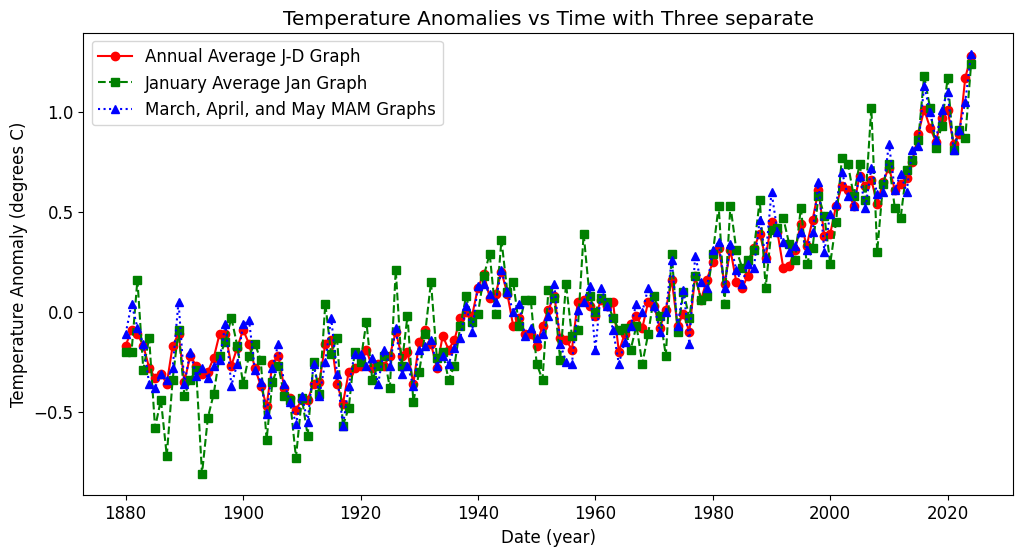

In [295]:
plt.figure(figsize=(12, 6))
plt.plot(temperature_year, temperature_JD, label = 'Annual Average J-D Graph', marker = 'o', linestyle = '-', color = "r")
plt.plot(temperature_year, temperature_Jan, label = 'January Average Jan Graph', marker = 's', linestyle = '--', color = "g")
plt.plot(temperature_year, temperature_MAM, label = 'March, April, and May MAM Graphs', marker = "^", linestyle = ':', color = "b")
plt.xlabel("Date (year)")
plt.ylabel("Temperature Anomaly (degrees C)")
plt.title("Temperature Anomalies vs Time with Three separate")
plt.legend()
plt.show()

All of the data follows an up down up down sawlike pattern, similar to the CO2 data. However, the January data is the most sporatic, jumping up and down with a higher amplitude than the J-D and MAM data. Those 2 datasets are almost overlapping at every point, but the J-D data has slightly higher peaks and slightly lower troughs most of the time. All the data sets have relatively the same "period" of oscillation and it seems like they have a linearly or quadratically increasing background as the y-values get consistently higher over time. It seems that if we're averaging more time, the amplitude of the graph gets smaller.

C. (10 pts) Now focus on making sense of trends in the annual average 'J-D' vs 'Year'. Define a
function that you think will fit the data, justify your choice, and carry out the fit. Does it make sense
to fit the entire range of data with one function? You may choose to divide the data into 2 halves and
fit each half separately. Justify your approach and your analysis.

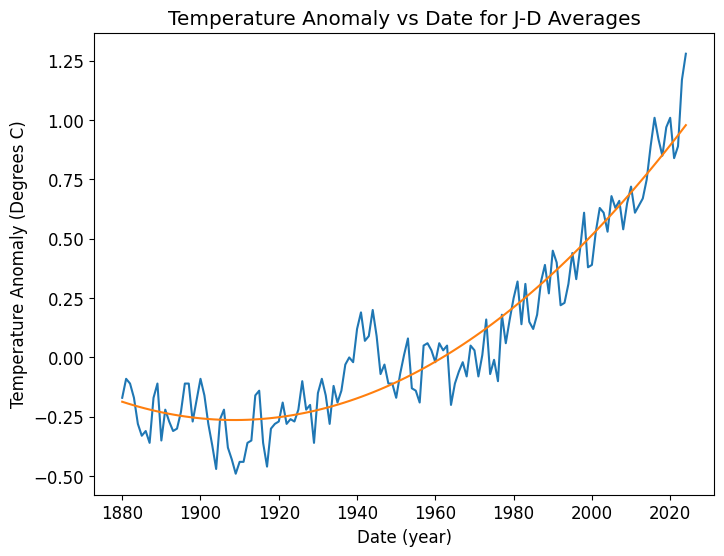

In [296]:
def Quadratic(x, a, b, c): #Defining a function for the quadratic fit
    """Model fit function: straight line, or polynomial of order 1"""
    return a*x*x + b*x + c

#Use curve_fit to fit the data:
pp = 3 #Number of fit parameters
nn = len(temperature_year) #Number of data points
guesses = (1, 1, 1) #Initial parameter guesses
(a, b, c),cc = curve_fit(Quadratic, temperature_year, temperature_JD, p0=guesses) #Store fit parameters in a, b
(ua,ub, uc) = 2*np.sqrt(np.diag(cc)) #2-sigma uncertainties of a, b, and c

#Plot data and model together
temperature_year_mod = np.linspace(temperature_year[0], temperature_year[-1], 100)  #Generate x values between initial and final x data
temperature_JD_mod = Quadratic(temperature_year_mod, a, b, c)   #Model fitting function values at the x points we have generated

plt.figure(figsize=(8, 6)) #Plotting the graph of all data
plt.rc('font', size=12)        
plt.plot(temperature_year, temperature_JD, label = "Line of Every Point") 
plt.xlabel('Date (year)')
plt.ylabel('Temperature Anomaly (Degrees C)')
plt.title ("Temperature Anomaly vs Date for J-D Averages")
plt.plot(temperature_year_mod, temperature_JD_mod, label = "Model Line of Best Fit") #Plotting the model
plt.show()

After a lengthy discussion with Prof. Tewari, I concluded that the best fit would be one quadratic fit. I weighted the debate between one linear, one linear and one quadratic, or two linear. For one linear, it was obvious that the quadratic curve would work way better seeing the way the data is distributed on the graph above. As for the two linear, I figured it would be hard to decipher where to end the first one and where to begin the second one, seeing as there is a big jump around 1940 and which line would be able to account for that gigantic error. Thus, I eliminated the two linear fit. As for one linear one quadratic, I thought that mixing functions would be too unreliable and I couldn't think of a valid way to connect both curves at the middle of them. Thus, I decided one quadratic fit would be best for this data. 

After running the code again, this time with one linear fit + one quadratic fit, and one linear fit alone, the highest chi square value ended up being the quadratic fit. I think the big spike around 1940 messes up the other fits alot. Thus, I used the quadratic fit.

D. (10 points) Graph the annual average vs year, and on the same graph, show the minimum and the
maximum recorded temperature in any given year as error bars (ask me for help on this if interested).
Discuss how recent trends in the global average temperature anomaly compares with these annual
fluctuations.

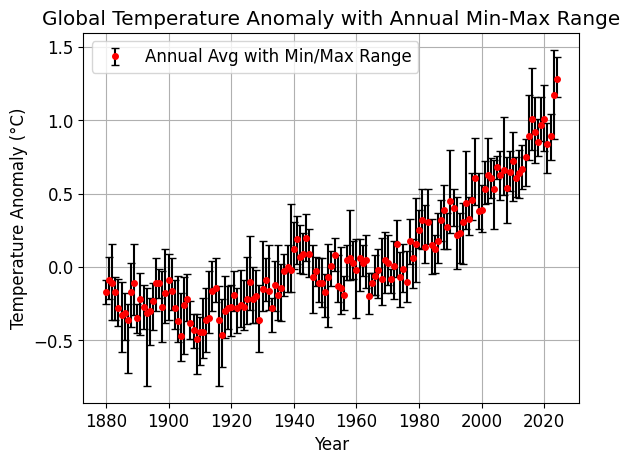

In [ ]:
temperature_monthly = temperature_data.iloc[:, 1:13].astype(float) #Using pandas iloc to import the 2nd-13th columns of the Temperature data

#Computing max and min monthly temperature anomaly for each year by scanning through an axis of 1 (1 whole row) to find the max and min values and record them
temperature_max = temperature_monthly.max(axis=1)
temperature_min = temperature_monthly.min(axis=1)

temperature_average_errors = np.array([temperature_JD - temperature_min, temperature_max - temperature_JD]) #Making double sided error bars for the graph using our max and min values

#Plotting the graph of averages vs year with the error bars created
plt.errorbar(temperature_year, temperature_JD, yerr = temperature_average_errors, fmt='o', color='red', ecolor='black', markersize=4, capsize=3, label="Annual Avg with Min/Max Range")
plt.xlabel('Year')
plt.ylabel('Temperature Anomaly (°C)')
plt.title('Global Temperature Anomaly with Annual Min-Max Range')
plt.legend()
plt.grid(True)
plt.show()

Looking at the graph produced, we can observe that the temperature fluctuations over the course of the 2 centuries are not solely accounted for by the error bars. This means there must be some alterior influence causing the anomolies to increase over time. Although if we were to alter the scale to say, a ten year period, we would not be able to say the same thing. This increase is likely rooted in global warming as the temperature increasing around 1 degree celcius over the course of 200 years seems consistent with the trajectory of how we are taking care of the Earth.

Part 4. Projecting future levels
The following article appeared in the New York Times in 2023, and discussed what climate data is
telling us, including the idea that a reduction in atmospheric aerosols might actually be accelerating
warming: https://www.nytimes.com/2023/10/13/opinion/climate-change-excessive-heat-2023.html. One
of the issues with prediction is that simply fitting the data is not enough – you need to have a model that
explains why something should have a linear or quadratic or other growth curve, and how that growth
may be limited by mitigating factors. But as a first pass, we will do the naïve thing – use your best fit to
predict what will happen if nothing changes and current trends continue, even if we have no physical
model to explain why the data behave this way.

A. (5 pts) Use your linear and quadratic fits to project the CO2 levels at Mauna Loa in 2058, 100
years since the beginning of the data set. Generate a plot with the data and your two fits (one
linear, one quadratic) with the time axis extended to 100 years, find the predicted value of the
CO2 concentration at t=100 years in both fits, and print these to the screen, with units.

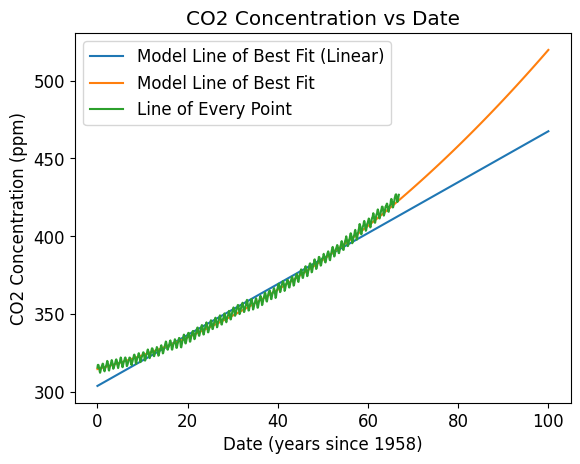

The predicted CO2 Concentration in 2058 via the linear fit is 467.44564604603954 ppm
The predicted CO2 Concentration in 2058 via the quadratic fit is 519.6444304145834 ppm


In [306]:
#Plot data and model together
co2_time_modl = np.linspace(co2_time_adjusted[0], 100, 100)  #Generate x values between initial and 2058
co2_concentration_modl = Linear(co2_time_modl, al, bl)   #Model fitting function values at the x points we have generated (linear)
plt.plot(co2_time_modl,co2_concentration_modl, label="Model Line of Best Fit (Linear)") #Plotting the model for linear until 2058

co2_time_modq = np.linspace(co2_time_adjusted[0], 100, 100)  #Generate x values between initial and 2058
co2_concentration_modq = Quadratic(co2_time_modq, aq, bq, cq)   #Model fitting function values at the x points we have generated (quadratic)
plt.plot(co2_time_modq,co2_concentration_modq, label = "Model Line of Best Fit") #Plotting the model for quadratic until 2058

plt.rc('font', size=12)         
plt.plot(co2_time_adjusted, co2_concentration, label = "Line of Every Point") #Plotting the graph of all data
plt.xlabel('Date (years since 1958)')
plt.ylabel('CO2 Concentration (ppm)')
plt.title ("CO2 Concentration vs Date")
plt.legend()
plt.show()

#Printing predicted 2058 values
print(f"The predicted CO2 Concentration in 2058 via the linear fit is {co2_concentration_modl[-1]} ppm")
print(f"The predicted CO2 Concentration in 2058 via the quadratic fit is {co2_concentration_modq[-1]} ppm")

B. (5 pts) Use the fits you generated in Part 3C to predict what the temperature anomaly will look
like in 2058, the same year as the CO2 levels prediction as in Part 4A. In a markdown cell,
compare this to what current climate models appear to be suggesting – how does your estimate
compare with these? Cite the reference you used for comparison.

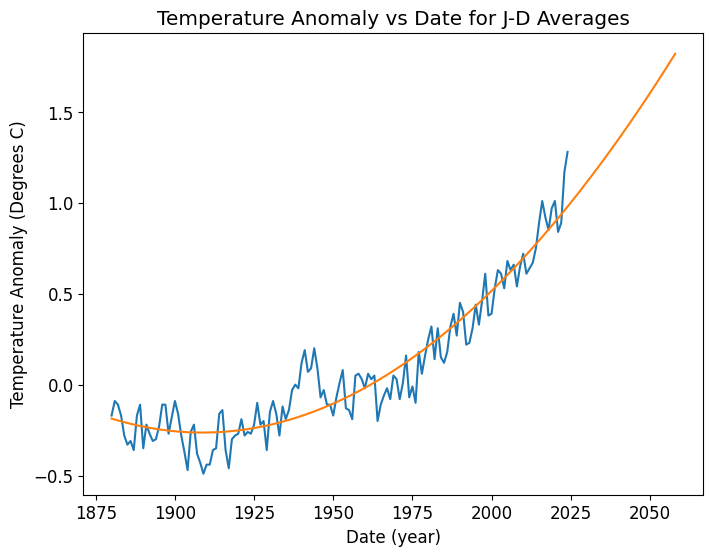

The predicted Temperature Anomaly in 2058 via the quadratic fit is 1.820068297761111 degrees C


In [301]:
#Plot data and model together
temperature_year_mod = np.linspace(temperature_year[0], 2058, 178)  #Generate x values between initial and final x data
temperature_JD_mod = Quadratic(temperature_year_mod, a, b, c)   #Model fitting function values at the x points we have generated

plt.figure(figsize=(8, 6)) #Plotting the graph of all data
plt.rc('font', size=12)        
plt.plot(temperature_year, temperature_JD, label = "Line of Every Point") 
plt.xlabel('Date (year)')
plt.ylabel('Temperature Anomaly (Degrees C)')
plt.title ("Temperature Anomaly vs Date for J-D Averages")
plt.plot(temperature_year_mod, temperature_JD_mod, label = "Model Line of Best Fit") #Plotting the model
plt.show()

print(f"The predicted Temperature Anomaly in 2058 via the quadratic fit is {temperature_JD_mod[-1]} degrees C")

The predicted Temperature Anamoly has a lowest bound of 1.76 degrees C in 2058 and a highest of 2.83 degrees C according to carbonbrief.org. However, they used a slightly higher baseline than us, indicating that their model will end up higher than ours. Attempting to account for this slightly higher baseline, we can subtract 0.1 degrees from the values they estimated, leading to a lowest bound of 1.66 degrees C and a highest of 2.73 degrees C. Our prediction of 1.82 degrees C is within that range, so our estimate is sound! However, that statistic is not very sound. It's kinda sad. As for CO2 levels, the ipcc.org used the same data we looked at to create predictive models. Their models have a lowest bound of around 425 ppm and a highest of around 610 ppm. Our linear prediction of 410 is a little low (evidently so), thus, we turn to our quadratic model of 519 ppm. The falls comfortably within the range. However, this data is extremely uncomfortable. Man, we gotta do something.

Sources:
https://www.carbonbrief.org/analysis-when-might-the-world-exceed-1-5c-and-2c-of-global-warming/#:~:text=Our%20analysis%20shows%20that:&text=Temperatures%20are%20expected%20to%20pass%202C%20in,2058%20with%20a%20median%20year%20of%202048.

https://www.ipcc-data.org/observ/ddc_co2.html